In [1]:
import numpy as np
import mne

In [2]:
root = mne.datasets.sample.data_path() / "MEG" / "sample"
evoked_file = root / "sample_audvis-ave.fif"
evokeds_list = mne.read_evokeds(
    evoked_file, baseline=(None, 0), proj=True, verbose=False
)

# Show condition names and baseline intervals
for e in evokeds_list:
    print(f"Condition: {e.comment}, baseline: {e.baseline}")

Condition: Left Auditory, baseline: (-0.19979521315838786, 0.0)
Condition: Right Auditory, baseline: (-0.19979521315838786, 0.0)
Condition: Left visual, baseline: (-0.19979521315838786, 0.0)
Condition: Right visual, baseline: (-0.19979521315838786, 0.0)


In [3]:
conds = ("aud/left", "aud/right", "vis/left", "vis/right")
evks = dict(zip(conds, evokeds_list))

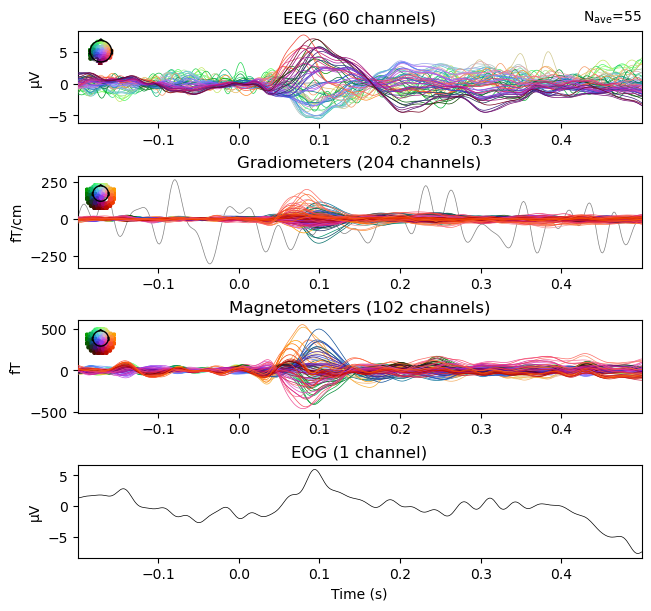

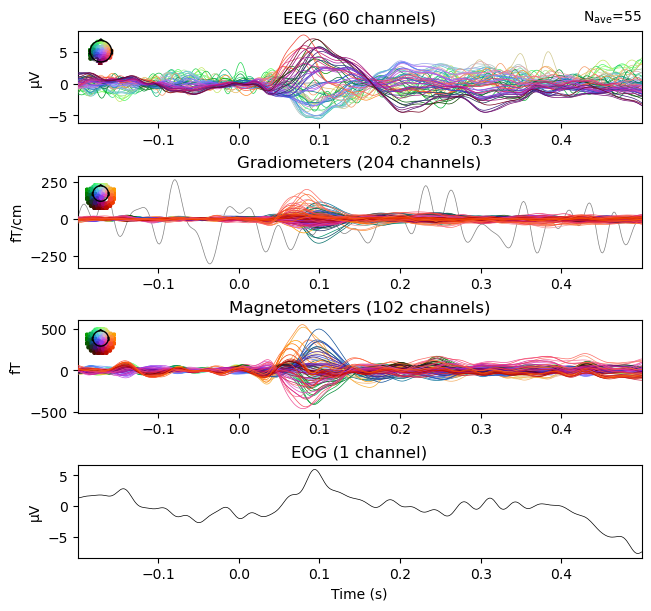

In [4]:
evks["aud/left"].plot(exclude=[])

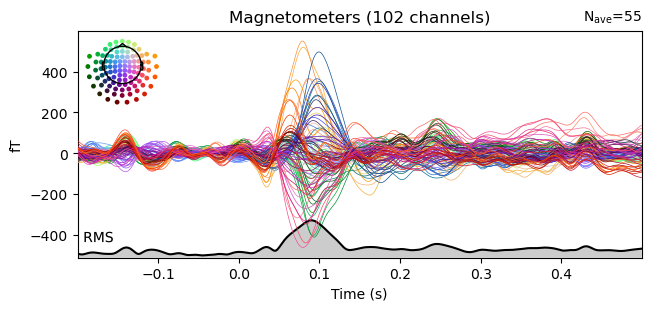

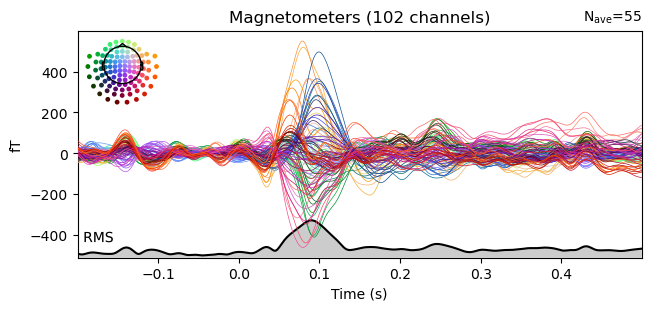

In [5]:
evks["aud/left"].plot(picks="mag", spatial_colors=True, gfp=True)

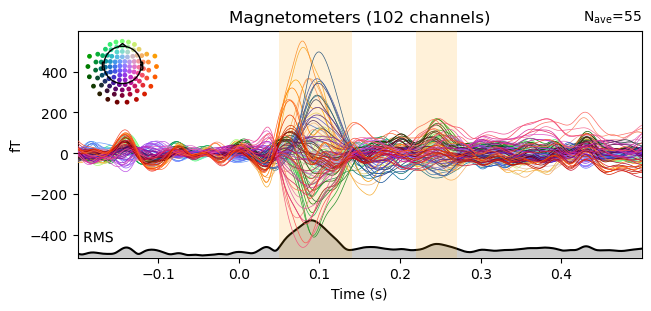

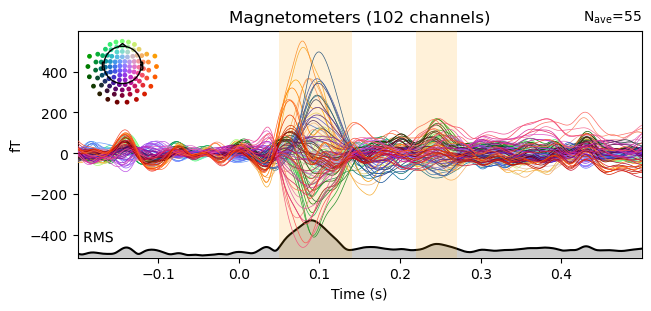

In [6]:
time_ranges_of_interest = [(0.05, 0.14), (0.22, 0.27)]
evks["aud/left"].plot(
    picks="mag", spatial_colors=True, gfp=True, highlight=time_ranges_of_interest
)

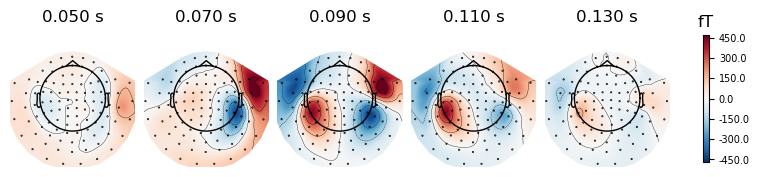

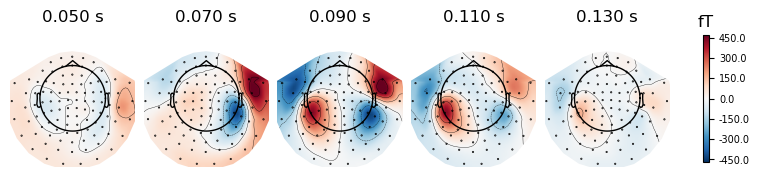

In [7]:
times = np.linspace(0.05, 0.13, 5)
evks["aud/left"].plot_topomap(ch_type="mag", times=times, colorbar=True)

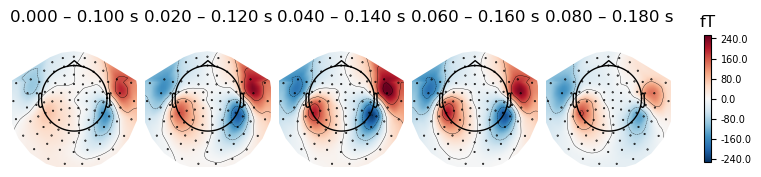

In [8]:
fig = evks["aud/left"].plot_topomap(ch_type="mag", times=times, average=0.1)

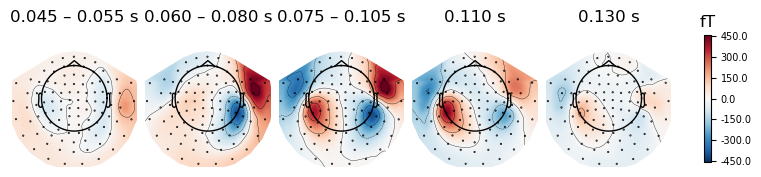

In [9]:
averaging_durations = [0.01, 0.02, 0.03, None, None]
fig = evks["aud/left"].plot_topomap(
    ch_type="mag", times=times, average=averaging_durations
)

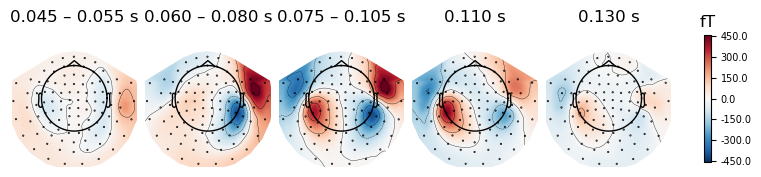

In [10]:
averaging_durations = [0.01, 0.02, 0.03, None, None]
fig = evks["aud/left"].plot_topomap(
    ch_type="mag", times=times, average=averaging_durations
)


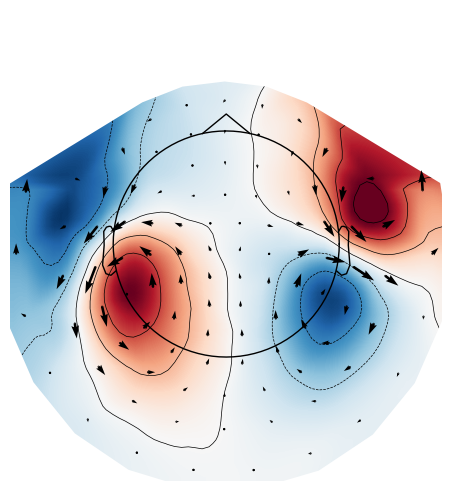

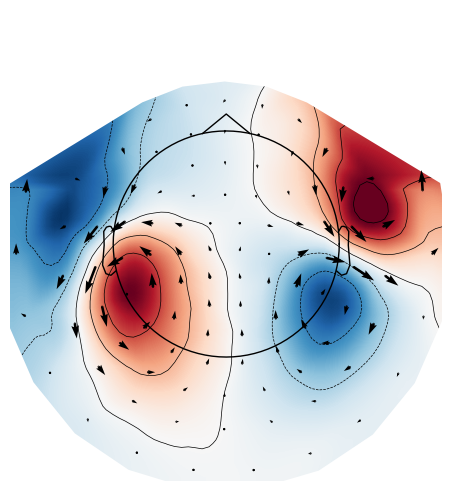

In [11]:
mags = evks["aud/left"].copy().pick(picks="mag")
mne.viz.plot_arrowmap(mags.data[:, 175], mags.info, extrapolate="local")

Projections have already been applied. Setting proj attribute to True.


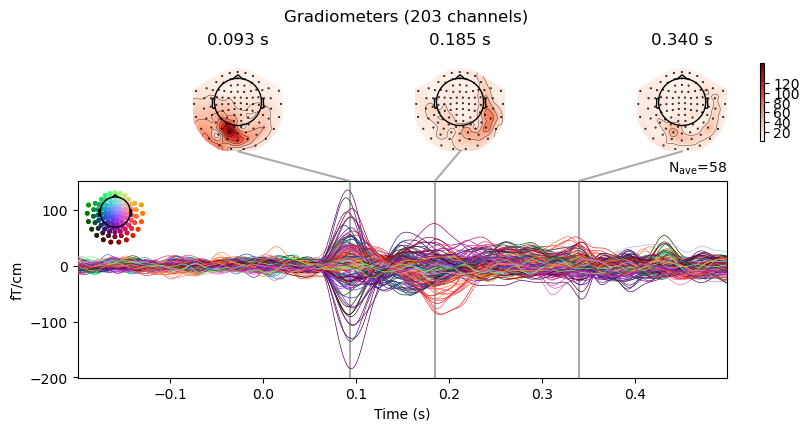

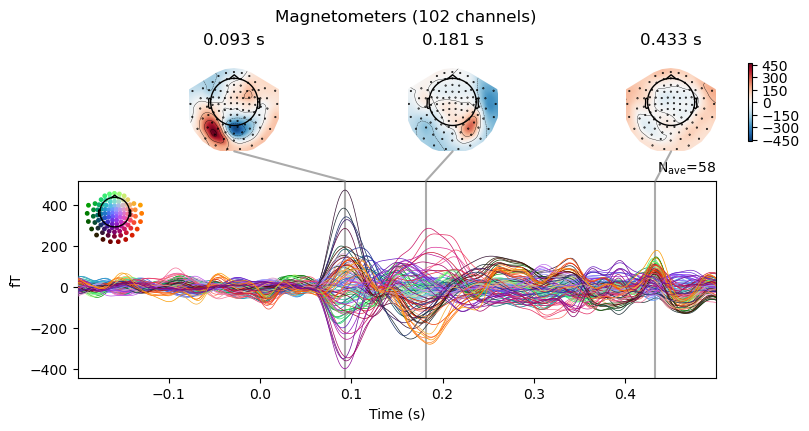

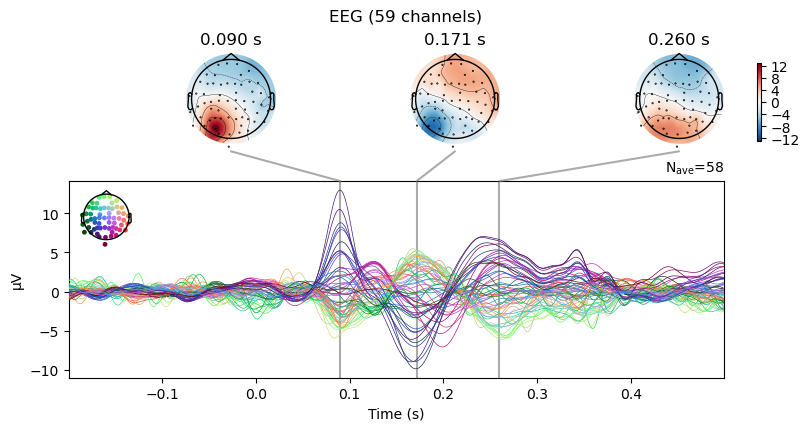

[<Figure size 800x420 with 6 Axes>,
 <Figure size 800x420 with 6 Axes>,
 <Figure size 800x420 with 6 Axes>]

In [12]:
evks["vis/right"].plot_joint()

combining channels using "mean"
combining channels using "mean"
combining channels using "mean"
combining channels using "mean"


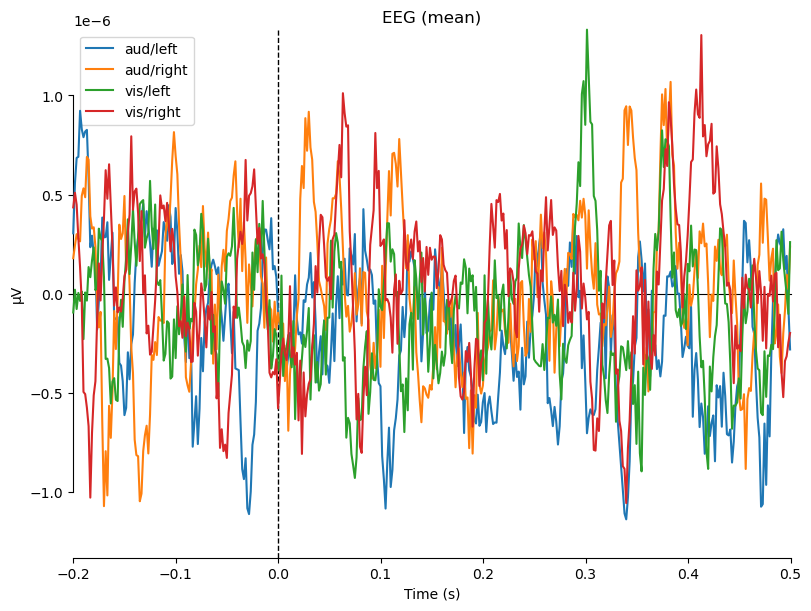

combining channels using "median"
combining channels using "median"
combining channels using "median"
combining channels using "median"


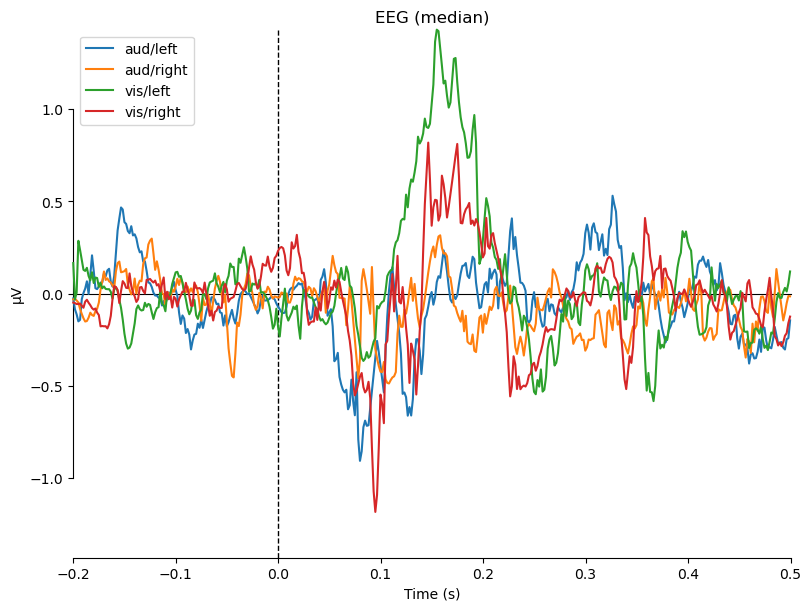

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


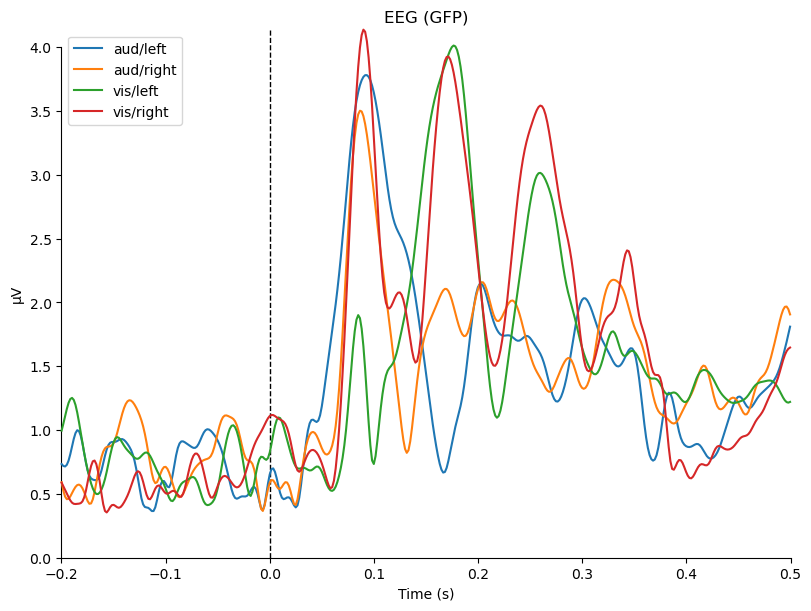

combining channels using "<function custom_func at 0x7f4c2caee340>"
combining channels using "<function custom_func at 0x7f4c2caee340>"
combining channels using "<function custom_func at 0x7f4c2caee340>"
combining channels using "<function custom_func at 0x7f4c2caee340>"


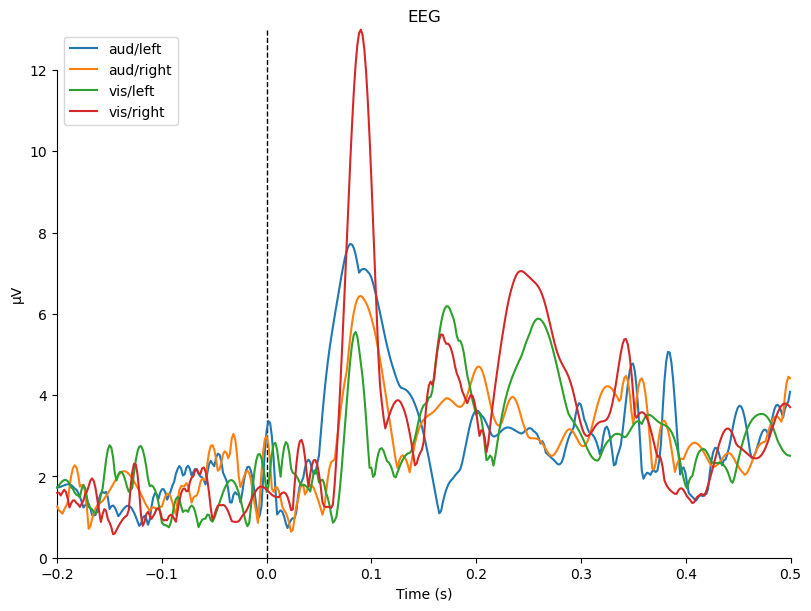

In [13]:
def custom_func(x):
    return x.max(axis=1)


for combine in ("mean", "median", "gfp", custom_func):
    mne.viz.plot_compare_evokeds(evks, picks="eeg", combine=combine)

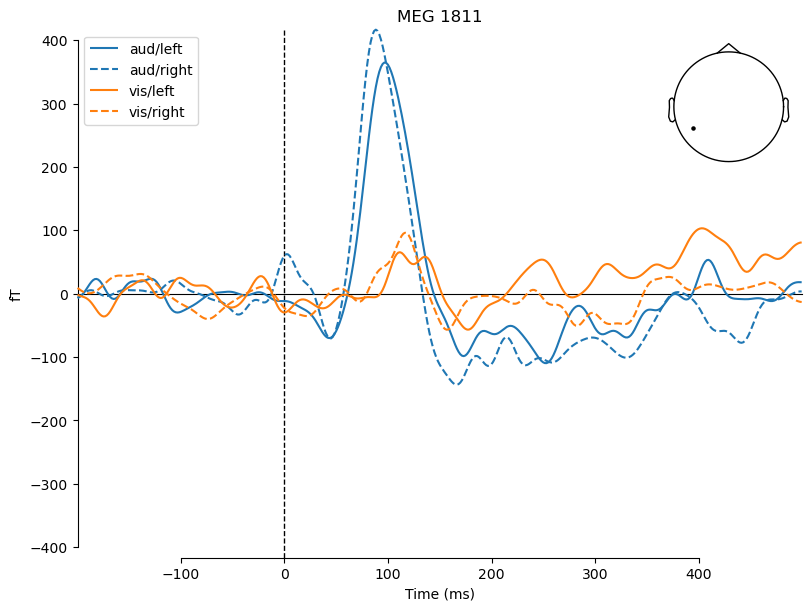

[<Figure size 800x600 with 2 Axes>]

In [14]:
mne.viz.plot_compare_evokeds(
    evks,
    picks="MEG 1811",
    colors=dict(aud=0, vis=1),
    linestyles=dict(left="solid", right="dashed"),
    time_unit="ms",
)

combining channels using RMS (mag channels)
combining channels using RMS (mag channels)
combining channels using RMS (mag channels)
combining channels using RMS (mag channels)
combining channels using RMS (mag channels)


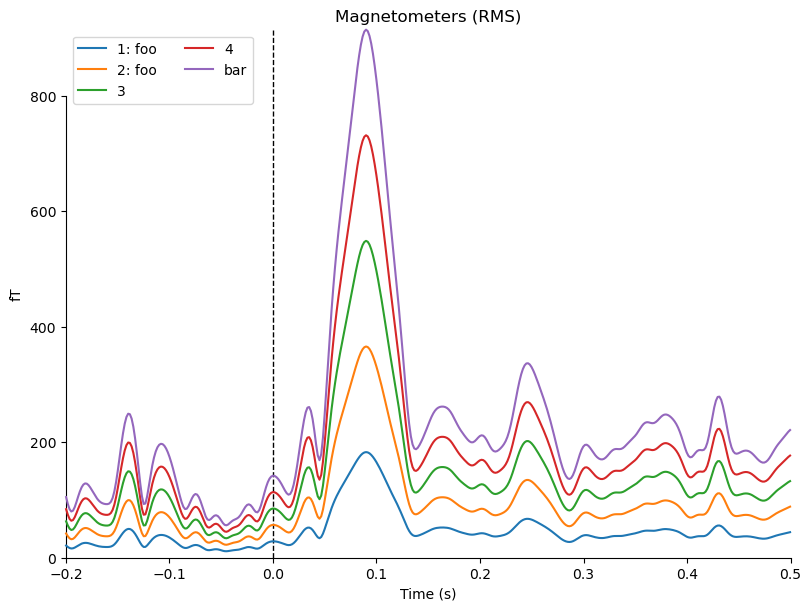

[<Figure size 800x600 with 1 Axes>]

In [15]:
temp_list = list()
for idx, _comment in enumerate(("foo", "foo", "", None, "bar"), start=1):
    _evk = evokeds_list[0].copy()
    _evk.comment = _comment
    _evk.data *= idx  # so we can tell the traces apart
    temp_list.append(_evk)

mne.viz.plot_compare_evokeds(temp_list, picks="mag")

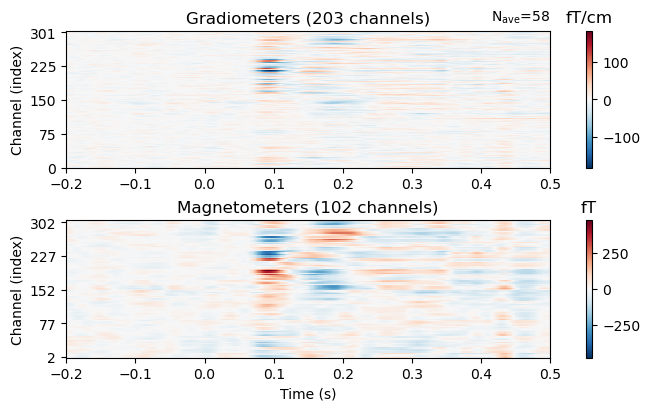

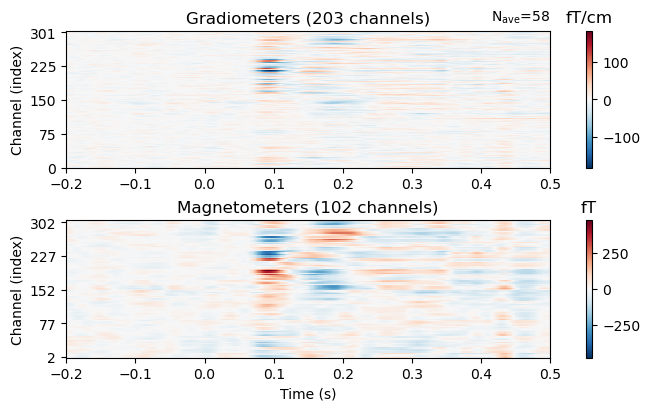

In [16]:
evks["vis/right"].plot_image(picks="meg")

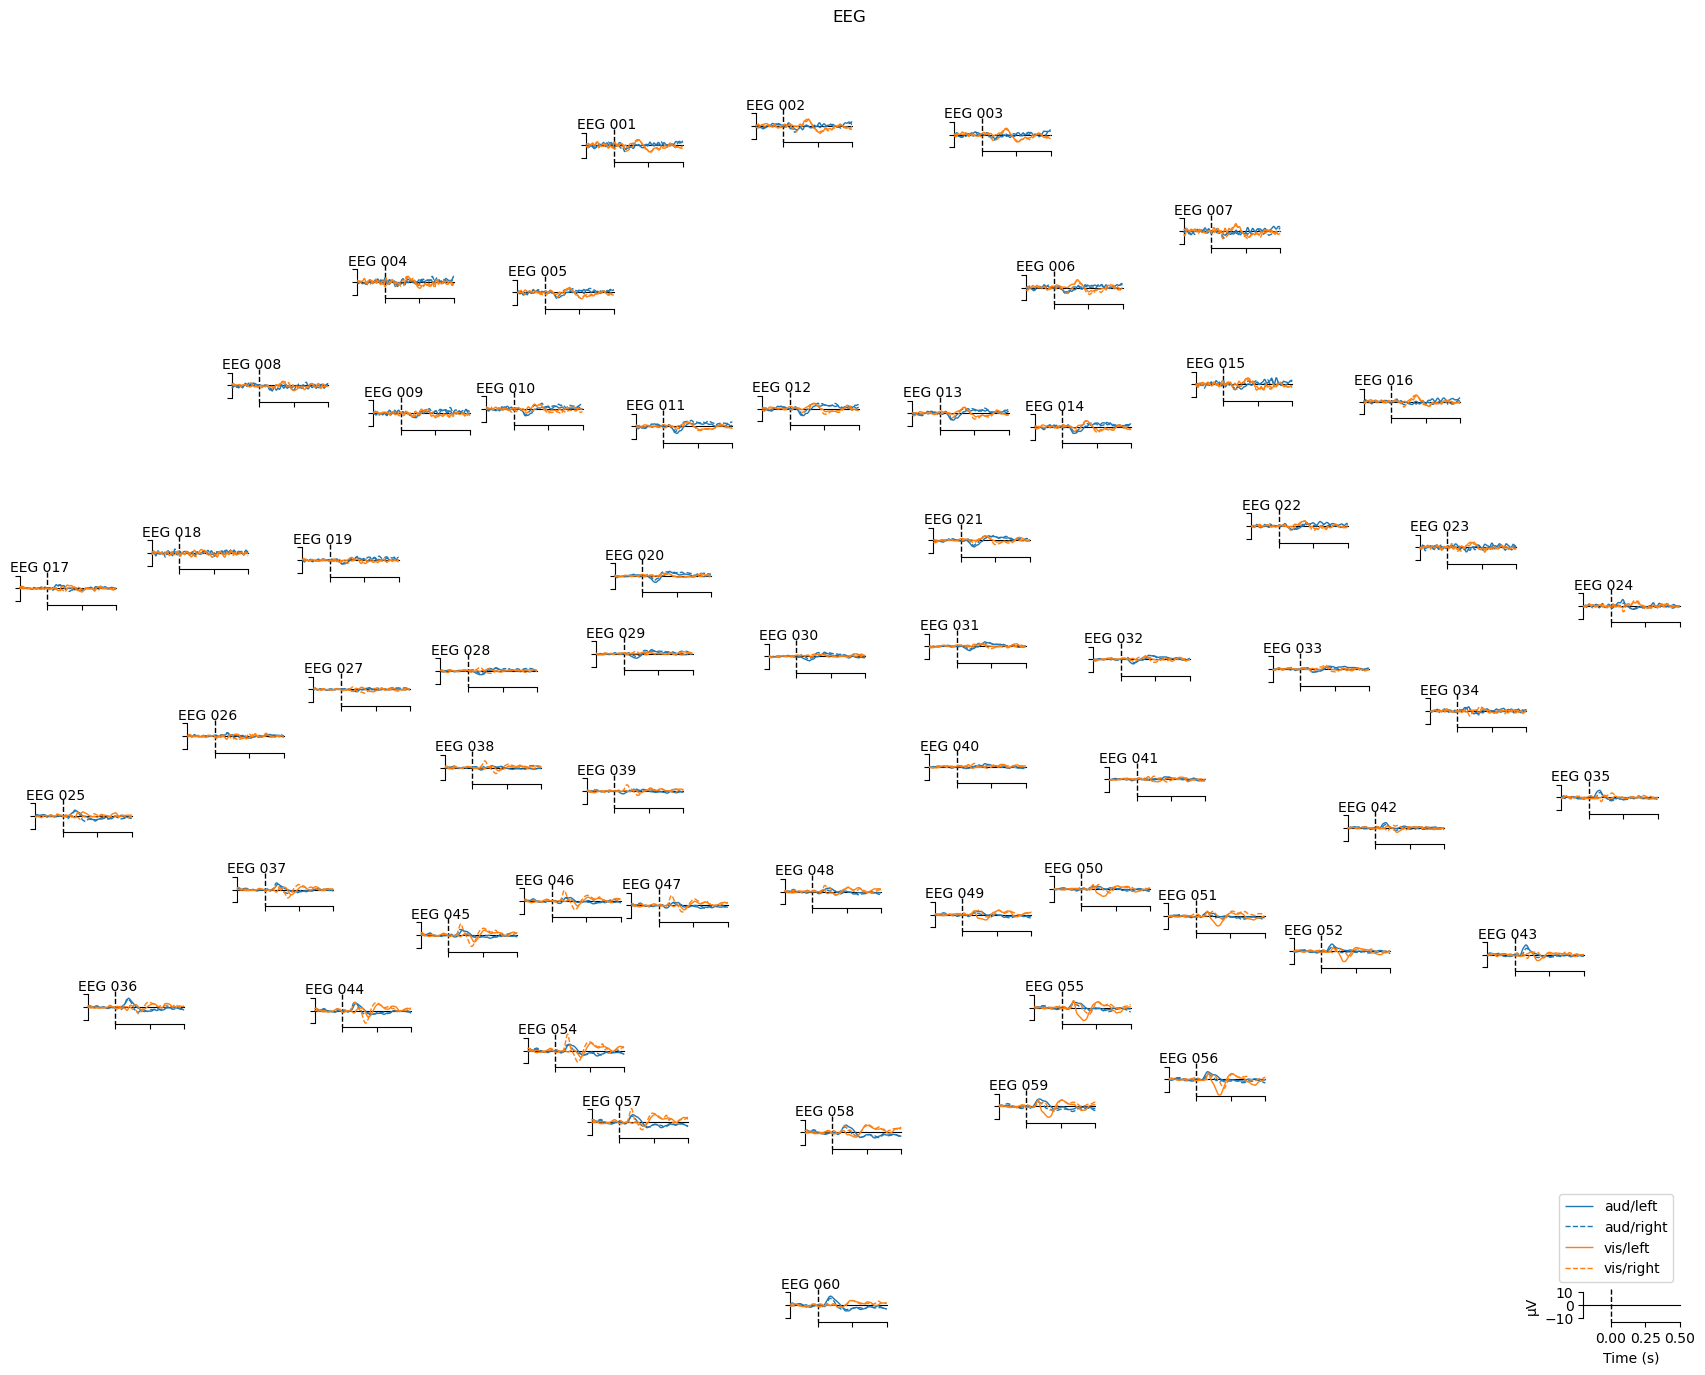

[<Figure size 1800x1400 with 60 Axes>]

In [17]:
mne.viz.plot_compare_evokeds(
    evks,
    picks="eeg",
    colors=dict(aud=0, vis=1),
    linestyles=dict(left="solid", right="dashed"),
    axes="topo",
    styles=dict(aud=dict(linewidth=1), vis=dict(linewidth=1)),
)

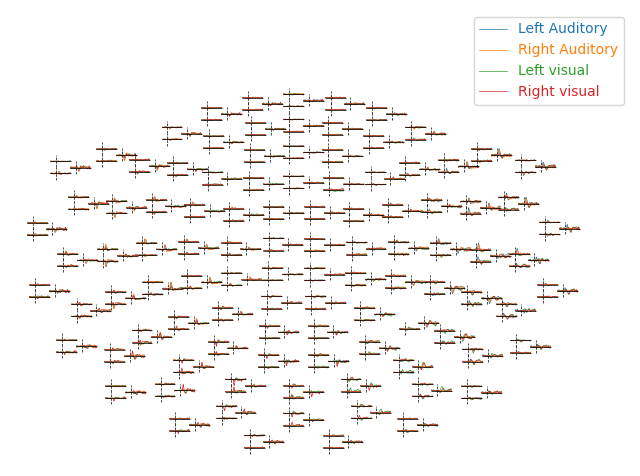

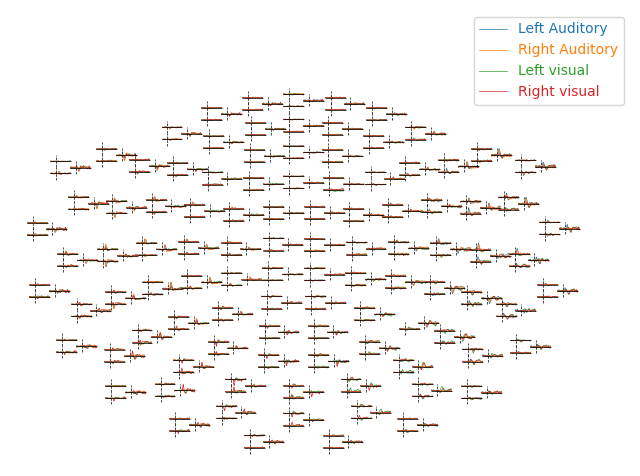

In [18]:
mne.viz.plot_evoked_topo(evokeds_list)

In [19]:
subjects_dir = root.parents[1] / "subjects"
trans_file = root / "sample_audvis_raw-trans.fif"

In [20]:
maps = mne.make_field_map(
    evks["aud/left"], trans=str(trans_file), subject="sample", subjects_dir=subjects_dir
)
evks["aud/left"].plot_field(maps, time=0.1)

Using surface from /root/mne_data/MNE-sample-data/subjects/sample/bem/sample-5120-5120-5120-bem.fif.
Getting helmet for system 306m
Prepare EEG mapping...
Computing dot products for 59 electrodes...
Computing dot products for 2562 surface locations...
Field mapping data ready
    Preparing the mapping matrix...
    Truncating at 21/59 components to omit less than 0.001 (0.00097)
    The map has an average electrode reference (2562 channels)
Prepare MEG mapping...
Computing dot products for 305 coils...
Computing dot products for 304 surface locations...
Field mapping data ready
    Preparing the mapping matrix...
    Truncating at 210/305 components to omit less than 0.0001 (9.9e-05)


RuntimeError: Could not load any valid 3D backend
pyvistaqt: No module named 'qtpy'
notebook: No module named 'ipyevents'

 install pyvistaqt, using pip or conda:
'pip install pyvistaqt'
'conda install -c conda-forge pyvistaqt'

 or install ipywidgets, if using a notebook backend
'pip install ipywidgets'
'conda install -c conda-forge ipywidgets'

In [ ]:
for ch_type in ("mag", "grad", "eeg"):
    evk = evks["aud/right"].copy().pick(ch_type)
    _map = mne.make_field_map(
        evk,
        trans=str(trans_file),
        subject="sample",
        subjects_dir=subjects_dir,
        meg_surf="head",
    )
    fig = evk.plot_field(_map, time=0.1)
    mne.viz.set_3d_title(fig, ch_type, size=20)